# S08 · Escalado y normalización
## NovaMarket · Grupo 05

Escalado de las variables numéricas con la técnica que corresponde a cada una, ajustando los
escaladores únicamente con el conjunto de entrenamiento para evitar fuga de datos.

Insumo: `S07_PD_Borja_DatasetSinOutliers.csv`, salida de la sesión de tratamiento de atípicos.
Salida: `S08_PD_Grupo05_DatasetEscalado.csv`.

El destino de este dataset es una segmentación de clientes, o sea un algoritmo basado en
distancias. Ese destino condiciona las decisiones que siguen: si las variables no comparten
escala, la de mayor magnitud domina la distancia y el resultado depende de las unidades de medida
en lugar del comportamiento del cliente.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

plt.style.use("default")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.facecolor": "white", "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

ENTRADA = "S07_PD_Borja_DatasetSinOutliers.csv"
SALIDA  = "S08_PD_Grupo05_DatasetEscalado.csv"

NUMERICAS = ["precio_unitario", "unidades_vendidas", "monto_compra",
             "edad_cliente", "peso_pedido_kg"]

df = pd.read_csv(ENTRADA, low_memory=False)

pd.DataFrame({"valor": [len(df), df.shape[1]]}, index=["filas", "columnas"])

,valor
filas,620000
columnas,34


---
# Parte 1 · Qué se escala y con qué técnica

## 1.1 · Qué columnas son relevantes

El dataset tiene varias columnas numéricas, pero no todas son variables de comportamiento.

In [2]:
candidatas = df.select_dtypes(include=[np.number]).columns.tolist()

clasificacion = []
for c in candidatas:
    if c in NUMERICAS:
        rol, escala = "variable de comportamiento", "sí"
    elif c == "codigo_postal":
        rol, escala = "identificador geográfico codificado como número", "no"
    elif c == "fuga_cliente":
        rol, escala = "bandera binaria, ya está en 0 y 1", "no"
    else:
        rol, escala = "bandera de control creada en sesiones previas", "no"
    clasificacion.append({"columna": c, "rol": rol, "se escala": escala})

pd.DataFrame(clasificacion).set_index("columna")

,rol,se escala
columna,,
codigo_postal,identificador geográfico codificado como número,no
precio_unitario,variable de comportamiento,sí
unidades_vendidas,variable de comportamiento,sí
monto_compra,variable de comportamiento,sí
edad_cliente,variable de comportamiento,sí
peso_pedido_kg,variable de comportamiento,sí
fuga_cliente,"bandera binaria, ya está en 0 y 1",no
peso_pedido_kg_original,bandera de control creada en sesiones previas,no


`codigo_postal` es un identificador: la distancia entre dos códigos postales no significa nada
numéricamente, así que escalarlo produciría una variable con aritmética falsa. `fuga_cliente` y las
banderas ya viven en 0 y 1, que es el rango al que se querría llevarlas.

Quedan las cinco variables de comportamiento.

## 1.2 · Perfil de las cinco variables

La elección de técnica no puede hacerse a ojo. Se mide primero.

In [3]:
def perfil(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return {
        "n": len(s), "nulos": None,
        "min": s.min(), "max": s.max(),
        "media": s.mean(), "mediana": s.median(), "desv": s.std(),
        "asimetría": s.skew(), "curtosis": s.kurt(),
        "% atípicos IQR": 100 * ((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).mean(),
        "rango/mediana": (s.max() - s.min()) / s.median() if s.median() else np.nan,
    }

filas = []
for c in NUMERICAS:
    p = perfil(df[c].dropna())
    p["nulos"] = int(df[c].isna().sum())
    p["variable"] = c
    filas.append(p)

tabla_perfil = pd.DataFrame(filas).set_index("variable").round(3)
tabla_perfil

,n,nulos,min,max,media,mediana,desv,asimetría,curtosis,% atípicos IQR,rango/mediana
variable,,,,,,,,,,,
precio_unitario,574000,46000,15100.0,899600.0,345022.145,312400.0,197524.778,0.536,-0.600,0.000,2.831
unidades_vendidas,584069,35931,0.0,5.0,1.890,1.0,1.178,1.130,0.456,11.805,5.000
monto_compra,540709,79291,0.0,4457500.0,651997.165,468600.0,598442.181,1.998,4.934,6.945,9.512
edad_cliente,584000,36000,18.0,75.0,46.515,47.0,16.736,-0.001,-1.199,0.000,1.213
peso_pedido_kg,620000,0,8.0,1298.2,67.876,11.7,247.461,4.221,16.085,5.000,110.274


## 1.3 · Las dos preguntas de decisión, respondidas por columna

**Pregunta 1: ¿quedan atípicos que puedan distorsionar los parámetros del escalador?**
Si la respuesta es sí, se descartan Min-Max y Z-score, porque el primero depende del mínimo y el
máximo y el segundo de la media y la desviación, y los tres estadísticos se mueven con un solo
valor extremo. La alternativa es el escalado robusto, que usa mediana e IQR.

**Pregunta 2: ¿conviene un rango acotado o conservar la noción de desviación?**
Min-Max entrega un rango [0, 1] interpretable y es la opción natural cuando los límites de la
variable son reales y estables. Z-score centra en cero y expresa cada valor en desviaciones
estándar, que es lo que interesa cuando la variable es simétrica y se va a usar en un algoritmo de
distancias.

In [4]:
decisiones = pd.DataFrame([
    {"variable": "precio_unitario", "técnica": "Min-Max",
     "P1 atípicos": "No, 0,00 % fuera del IQR",
     "P2 rango o desviación": "Rango acotado y estable, de 15.100 a 899.600"},
    {"variable": "unidades_vendidas", "técnica": "Min-Max",
     "P1 atípicos": "El IQR marca 11,8 %, pero son niveles legítimos",
     "P2 rango o desviación": "Discreta con seis niveles, de 0 a 5"},
    {"variable": "monto_compra", "técnica": "Robusto",
     "P1 atípicos": "Sí, 6,94 % con asimetría 2,00",
     "P2 rango o desviación": "Ninguna de las dos: mediana e IQR"},
    {"variable": "edad_cliente", "técnica": "Z-score",
     "P1 atípicos": "No, 0,00 % fuera del IQR",
     "P2 rango o desviación": "Simétrica, asimetría −0,00, sirve la desviación"},
    {"variable": "peso_pedido_kg", "técnica": "Robusto",
     "P1 atípicos": "Sí, 5,00 %, y además es bimodal",
     "P2 rango o desviación": "Ninguna de las dos: mediana e IQR"},
]).set_index("variable")

decisiones

,técnica,P1 atípicos,P2 rango o desviación
variable,,,
precio_unitario,Min-Max,"No, 0,00 % fuera del IQR","Rango acotado y estable, de 15.100 a 899.600"
unidades_vendidas,Min-Max,"El IQR marca 11,8 %, pero son niveles legítimos","Discreta con seis niveles, de 0 a 5"
monto_compra,Robusto,"Sí, 6,94 % con asimetría 2,00",Ninguna de las dos: mediana e IQR
edad_cliente,Z-score,"No, 0,00 % fuera del IQR","Simétrica, asimetría −0,00, sirve la desviación"
peso_pedido_kg,Robusto,"Sí, 5,00 %, y además es bimodal",Ninguna de las dos: mediana e IQR


### Justificación de cada columna

**`precio_unitario` con Min-Max.** No tiene ni un solo valor fuera del rango intercuartílico, así
que el mínimo y el máximo son estadísticos confiables y no van a quedar fijados por un dato
anómalo. Su curtosis de −0,60 indica una distribución aplanada, sin la campana que justificaría un
z-score, y su rango es un intervalo de precios real del catálogo. Llevarlo a [0, 1] produce una
variable directamente interpretable: 0 es el artículo más barato y 1 el más caro.

**`unidades_vendidas` con Min-Max.** El caso que más se presta a error. El criterio del IQR marca
11,8 % de atípicos, y eso invitaría a usar escalado robusto. Sin embargo esa cifra es un artefacto:
la variable solo toma seis valores enteros, con Q1 = 1 y Q3 = 2, de modo que el IQR vale 1 y el
límite superior queda en 3,5. Todo pedido de 4 o 5 unidades cae fuera por construcción, sin que
haya nada anómalo en comprar cuatro artículos. Como los límites 0 y 5 son reales y fijos, Min-Max
conserva los seis niveles equiespaciados y mantiene el significado de la variable.

**`monto_compra` con escalado robusto.** Tiene asimetría de 2,00 y curtosis de 4,93, o sea una cola
derecha larga y pesada, con 6,94 % de valores fuera del IQR. Esos valores son legítimos, porque el
monto es el producto de precio por unidades y las compras grandes existen, pero son suficientes
para arrastrar la media y la desviación. Con z-score la mayoría de los clientes quedaría comprimida
cerca de cero mientras unos pocos ocupan todo el rango. El escalado robusto centra en la mediana y
divide por el IQR, así que la referencia la fija el cliente típico y no la cola.

**`edad_cliente` con Z-score.** Es la única variable simétrica del conjunto: asimetría de −0,00 y
ningún valor fuera del IQR tras la limpieza de la sesión anterior. Su media y su desviación son
estadísticos estables, que es la condición que pide el z-score. Y como el destino es una
segmentación por distancias, expresar la edad en desviaciones estándar hace que aporte una varianza
comparable a la de las demás variables, en lugar de quedar aplastada por tener un rango de solo 57
unidades frente a los cientos de miles de las variables monetarias.

**`peso_pedido_kg` con escalado robusto.** Es el caso más claro de los cinco. La sesión anterior
documentó que es bimodal: 589.000 pedidos entre 8 y 15 kg, ningún pedido entre 15 y 900 kg, y un
bloque de 31.000 por encima de 900. Con Min-Max, el 95 % de los datos quedaría comprimido en la
primera centésima del rango, porque el máximo lo fija el bloque alto. Con z-score pasaría algo
parecido, porque la desviación está inflada por ese bloque. La mediana y el IQR describen el grupo
mayoritario sin dejarse arrastrar, y el bloque alto queda simplemente lejos, que es exactamente lo
que debe pasar si de verdad es otra población.

---
# Parte 2 · División en entrenamiento y prueba

## 2.1 · La división va primero

Esta celda se ejecuta **antes** de crear ningún escalador. El orden no es una preferencia de
estilo: si un escalador se ajusta con el dataset completo, aprende el mínimo, el máximo, la media o
la mediana de datos que después va a evaluar como si no los conociera, y la evaluación deja de ser
honesta. Eso es la fuga de datos.

La partición es aleatoria simple y no estratificada, porque el destino es una segmentación no
supervisada y no existe una variable objetivo por la cual estratificar.

In [5]:
train, test = train_test_split(df, test_size=0.20, random_state=42)

pd.DataFrame({
    "filas": [len(train), len(test), len(df)],
    "proporción": [round(len(train) / len(df), 3), round(len(test) / len(df), 3), 1.0],
}, index=["entrenamiento", "prueba", "total"])

,filas,proporción
entrenamiento,496000,0.8
prueba,124000,0.2
total,620000,1.0


## 2.2 · Por qué el orden importa, demostrado con números

Se comparan los parámetros que aprendería cada escalador ajustado solo con entrenamiento contra los
que aprendería ajustado con el dataset completo. Si fueran idénticos, la fuga sería inofensiva.
No lo son.

In [6]:
comparacion_fuga = []
for c, Esc, p1, p2 in [
    ("precio_unitario",   MinMaxScaler,    "data_min_",  "data_max_"),
    ("unidades_vendidas", MinMaxScaler,    "data_min_",  "data_max_"),
    ("monto_compra",      RobustScaler,    "center_",    "scale_"),
    ("edad_cliente",      StandardScaler,  "mean_",      "scale_"),
    ("peso_pedido_kg",    RobustScaler,    "center_",    "scale_"),
]:
    correcto = Esc().fit(train[[c]])
    con_fuga = Esc().fit(df[[c]])
    a1, a2 = getattr(correcto, p1)[0], getattr(correcto, p2)[0]
    b1, b2 = getattr(con_fuga, p1)[0], getattr(con_fuga, p2)[0]
    comparacion_fuga.append({
        "variable": c, "escalador": Esc.__name__,
        f"param 1": p1, "solo train": round(a1, 4), "con todo": round(b1, 4),
        f"param 2": p2, "solo train ": round(a2, 4), "con todo ": round(b2, 4),
        "difieren": (a1 != b1) or (a2 != b2),
    })

pd.DataFrame(comparacion_fuga).set_index("variable")

,escalador,param 1,solo train,con todo,param 2,solo train,con todo,difieren
variable,,,,,,,,
precio_unitario,MinMaxScaler,data_min_,15100.0000,15100.0000,data_max_,899600.0000,899600.0000,False
unidades_vendidas,MinMaxScaler,data_min_,0.0000,0.0000,data_max_,5.0000,5.0000,False
monto_compra,RobustScaler,center_,468600.0000,468600.0000,scale_,566600.0000,566900.0000,True
edad_cliente,StandardScaler,mean_,46.5285,46.5146,scale_,16.7383,16.7356,True
peso_pedido_kg,RobustScaler,center_,11.7000,11.7000,scale_,3.7000,3.7000,False


In [7]:
cambian = pd.DataFrame(comparacion_fuga).set_index("variable")["difieren"]

pd.DataFrame({"valor": [
    int(cambian.sum()), len(cambian),
    ", ".join(cambian[cambian].index) or "ninguna",
    ", ".join(cambian[~cambian].index) or "ninguna",
]}, index=["variables cuyos parámetros cambian", "variables evaluadas",
           "cuáles cambian", "cuáles coinciden"])

,valor
variables cuyos parámetros cambian,2
variables evaluadas,5
cuáles cambian,"monto_compra, edad_cliente"
cuáles coinciden,"precio_unitario, unidades_vendidas, peso_pedid..."


Las diferencias son pequeñas, porque el conjunto de prueba es grande y se parece al de
entrenamiento. Pero el punto no es su tamaño: es que existen. Un parámetro contaminado por el
conjunto de prueba invalida la evaluación aunque la contaminación esté en los decimales.

Donde los parámetros coinciden también hay explicación: los valores extremos de esa variable
cayeron en el conjunto de entrenamiento, así que el mínimo y el máximo resultan iguales. Es una
casualidad de esta partición, no una garantía, y no cambia el procedimiento.

---
# Parte 3 · Ajuste y transformación

## 3.1 · Un escalador por columna, ajustado solo con entrenamiento

`fit()` se llama exclusivamente sobre `train`. `transform()` se llama sobre los dos conjuntos.

In [8]:
PLAN = {
    "precio_unitario":   MinMaxScaler(),
    "unidades_vendidas": MinMaxScaler(),
    "monto_compra":      RobustScaler(),
    "edad_cliente":      StandardScaler(),
    "peso_pedido_kg":    RobustScaler(),
}

escaladores = {}
train_esc = train.copy()
test_esc = test.copy()

for col, escalador in PLAN.items():
    escalador.fit(train[[col]])                       # ajuste: solo entrenamiento
    train_esc[col + "_esc"] = escalador.transform(train[[col]])   # transformación: ambos
    test_esc[col + "_esc"] = escalador.transform(test[[col]])
    escaladores[col] = escalador

pd.DataFrame({
    "escalador": [type(e).__name__ for e in escaladores.values()],
    "ajustado con": ["solo entrenamiento"] * len(escaladores),
}, index=list(escaladores.keys()))

,escalador,ajustado con
precio_unitario,MinMaxScaler,solo entrenamiento
unidades_vendidas,MinMaxScaler,solo entrenamiento
monto_compra,RobustScaler,solo entrenamiento
edad_cliente,StandardScaler,solo entrenamiento
peso_pedido_kg,RobustScaler,solo entrenamiento


## 3.2 · Parámetros aprendidos

Cada escalador guarda los estadísticos que aprendió del entrenamiento. Son los que se aplicarán
también a la prueba y a cualquier dato futuro.

In [9]:
params = []
for col, e in escaladores.items():
    if isinstance(e, MinMaxScaler):
        params.append({"variable": col, "escalador": "MinMaxScaler",
                       "parámetro 1": f"mínimo = {e.data_min_[0]:,.2f}",
                       "parámetro 2": f"máximo = {e.data_max_[0]:,.2f}"})
    elif isinstance(e, StandardScaler):
        params.append({"variable": col, "escalador": "StandardScaler",
                       "parámetro 1": f"media = {e.mean_[0]:,.4f}",
                       "parámetro 2": f"desviación = {e.scale_[0]:,.4f}"})
    else:
        params.append({"variable": col, "escalador": "RobustScaler",
                       "parámetro 1": f"mediana = {e.center_[0]:,.2f}",
                       "parámetro 2": f"IQR = {e.scale_[0]:,.2f}"})

pd.DataFrame(params).set_index("variable")

,escalador,parámetro 1,parámetro 2
variable,,,
precio_unitario,MinMaxScaler,"mínimo = 15,100.00","máximo = 899,600.00"
unidades_vendidas,MinMaxScaler,mínimo = 0.00,máximo = 5.00
monto_compra,RobustScaler,"mediana = 468,600.00","IQR = 566,600.00"
edad_cliente,StandardScaler,media = 46.5285,desviación = 16.7383
peso_pedido_kg,RobustScaler,mediana = 11.70,IQR = 3.70


## 3.3 · Verificación de que no hubo fuga

La prueba más directa: si el escalador aprendió únicamente del entrenamiento, entonces el rango de
entrenamiento cae exactamente donde debe y el de prueba no tiene por qué coincidir.

En una variable con Min-Max, el entrenamiento debe llegar exactamente a 0 y a 1, porque su mínimo y
su máximo son los que definieron la escala. La prueba, en cambio, se queda dentro o se sale por
poco, según dónde estén sus propios extremos. **Si la prueba también diera exactamente 0 y 1, sería
señal de que el escalador la vio durante el ajuste.**

In [10]:
verif = []
for col in PLAN:
    a = train_esc[col + "_esc"]
    b = test_esc[col + "_esc"]
    verif.append({
        "variable": col, "escalador": type(escaladores[col]).__name__,
        "train mín": round(a.min(), 6), "train máx": round(a.max(), 6),
        "test mín": round(b.min(), 6), "test máx": round(b.max(), 6),
        "test toca los bordes exactos": bool(
            np.isclose(a.min(), b.min()) and np.isclose(a.max(), b.max())),
    })

tabla_verif = pd.DataFrame(verif).set_index("variable")
display(tabla_verif)

pd.DataFrame({"valor": [
    int((~tabla_verif["test toca los bordes exactos"]).sum()),
    len(tabla_verif),
    "sin fuga" if (~tabla_verif["test toca los bordes exactos"]).any() else "revisar",
]}, index=["variables donde prueba NO toca los bordes exactos",
           "variables evaluadas", "lectura"])

,escalador,train mín,train máx,test mín,test máx,test toca los bordes exactos
variable,,,,,,
precio_unitario,MinMaxScaler,0.000000,1.000000,0.001583,0.999096,False
unidades_vendidas,MinMaxScaler,0.000000,1.000000,0.000000,1.000000,True
monto_compra,RobustScaler,-0.827038,7.040064,-0.827038,7.004765,False
edad_cliente,StandardScaler,-1.704383,1.700983,-1.704383,1.700983,True
peso_pedido_kg,RobustScaler,-1.000000,347.702703,-1.000000,347.702703,True


,valor
variables donde prueba NO toca los bordes exactos,2
variables evaluadas,5
lectura,sin fuga


In [11]:
# Los nulos deben seguir siendo nulos: escalar no imputa
pd.DataFrame({
    "nulos originales": [int(df[c].isna().sum()) for c in PLAN],
    "nulos train escalado": [int(train_esc[c + "_esc"].isna().sum()) for c in PLAN],
    "nulos test escalado": [int(test_esc[c + "_esc"].isna().sum()) for c in PLAN],
}, index=list(PLAN.keys())).assign(
    suma=lambda t: t["nulos train escalado"] + t["nulos test escalado"])

,nulos originales,nulos train escalado,nulos test escalado,suma
precio_unitario,46000,36913,9087,46000
unidades_vendidas,35931,28714,7217,35931
monto_compra,79291,63543,15748,79291
edad_cliente,36000,28867,7133,36000
peso_pedido_kg,0,0,0,0


Los nulos que venían de la sesión de atípicos se conservan como nulos. El escalado no inventa
valores donde no los había, y la suma de nulos de los dos conjuntos coincide con el original.

---
# Parte 4 · Comparación visual antes y después

## 4.1 · Histogramas

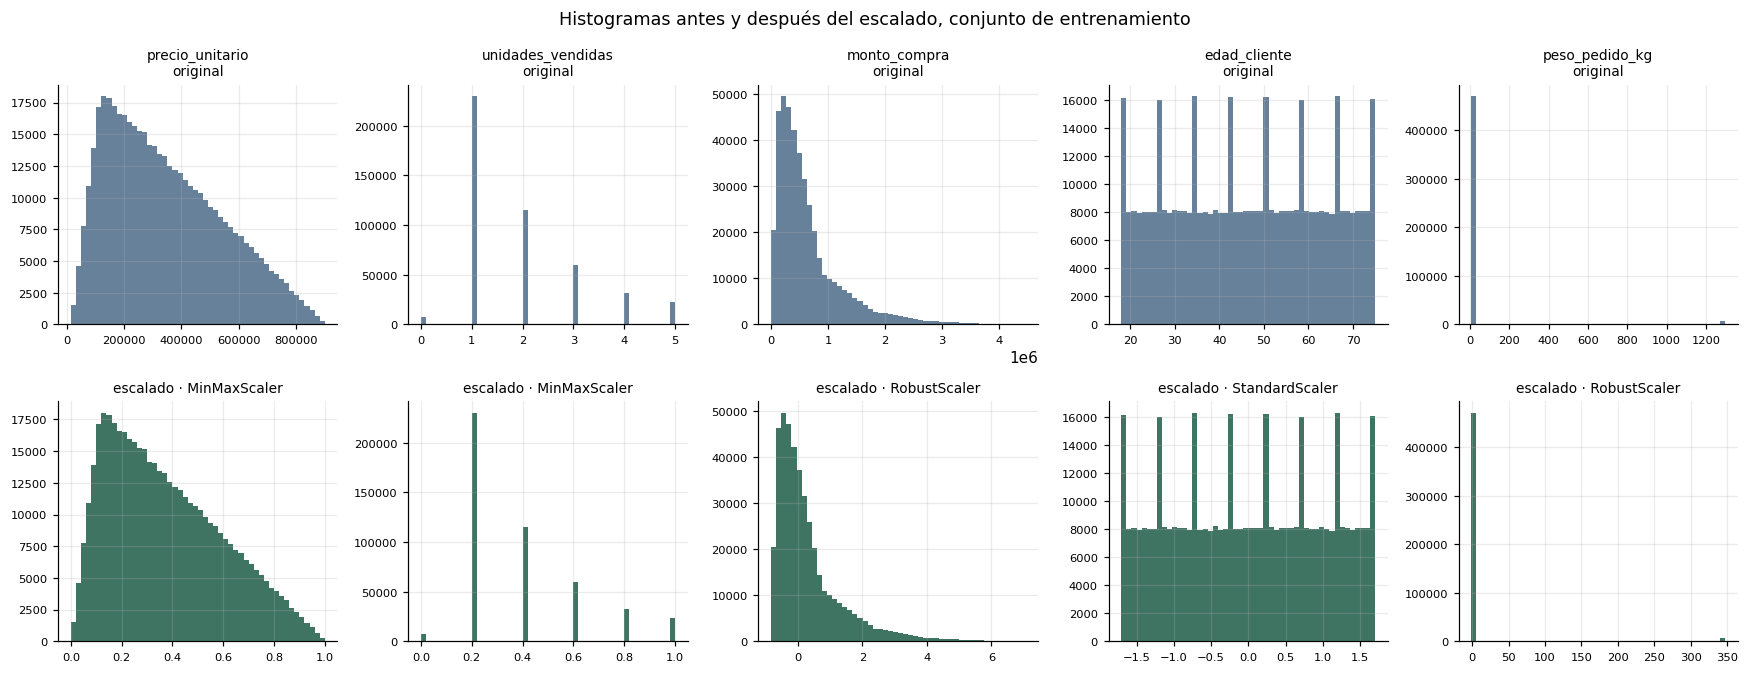

In [12]:
fig, ax = plt.subplots(2, 5, figsize=(16, 6.2))
for i, col in enumerate(PLAN):
    ax[0, i].hist(train[col].dropna(), bins=50, color="#4C6B8A", alpha=0.85)
    ax[0, i].set_title(f"{col}\noriginal", fontsize=9)
    ax[1, i].hist(train_esc[col + "_esc"].dropna(), bins=50, color="#1D5C48", alpha=0.85)
    ax[1, i].set_title(f"escalado · {type(escaladores[col]).__name__}", fontsize=9)
    for j in (0, 1):
        ax[j, i].tick_params(labelsize=7.5)
fig.suptitle("Histogramas antes y después del escalado, conjunto de entrenamiento", fontsize=11.5)
fig.tight_layout()
plt.show()

**La forma no cambia, solo cambia el eje.** Cada histograma de abajo es idéntico en silueta al
de arriba: mismo número de modas, misma dirección de la asimetría, mismos huecos. Lo único que se
modificó son los números del eje horizontal.

Eso es lo que debe pasar. Las tres técnicas son transformaciones lineales de la forma
`(x − a) / b`, y una transformación lineal no puede crear ni destruir modas, ni cambiar el orden de
los datos. Si la forma hubiera cambiado, sería señal de que se aplicó una transformación
logarítmica o una potencia, que son otra cosa.

El caso de `peso_pedido_kg` es el más elocuente: la bimodalidad sigue ahí después de escalar,
porque el escalado no arregla una distribución bimodal ni pretende hacerlo.

## 4.2 · Boxplots

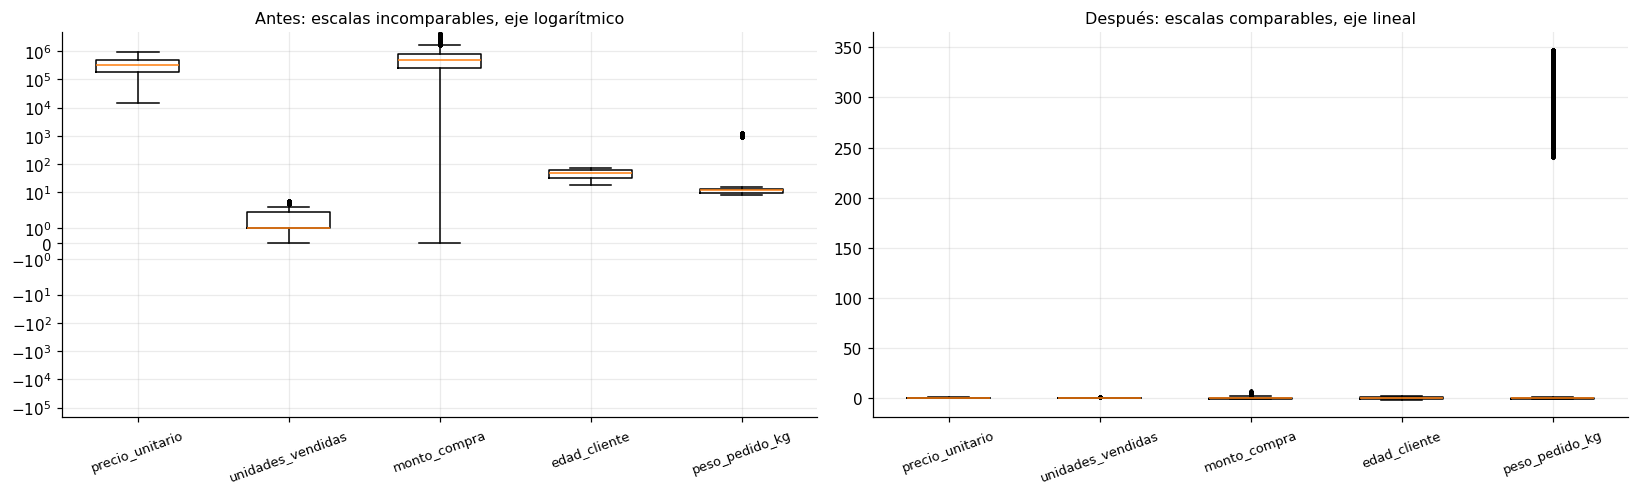

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))

datos_orig = [train[c].dropna() for c in PLAN]
ax[0].boxplot(datos_orig, widths=0.55,
              flierprops=dict(marker=".", markersize=2.5, alpha=0.2))
ax[0].set_xticks(range(1, len(PLAN) + 1))
ax[0].set_xticklabels(list(PLAN))
ax[0].set_yscale("symlog")
ax[0].set_title("Antes: escalas incomparables, eje logarítmico", fontsize=10.5)
ax[0].tick_params(axis="x", rotation=20, labelsize=8.5)

datos_esc = [train_esc[c + "_esc"].dropna() for c in PLAN]
ax[1].boxplot(datos_esc, widths=0.55,
              flierprops=dict(marker=".", markersize=2.5, alpha=0.2))
ax[1].set_xticks(range(1, len(PLAN) + 1))
ax[1].set_xticklabels(list(PLAN))
ax[1].set_title("Después: escalas comparables, eje lineal", fontsize=10.5)
ax[1].tick_params(axis="x", rotation=20, labelsize=8.5)

fig.tight_layout()
plt.show()

**Este par de gráficos es el argumento central de la entrega.**

A la izquierda las cinco cajas están en un eje logarítmico, y aun así no se pueden comparar: el
monto vive en cientos de miles y la edad en decenas. En una segmentación por distancias, esa
diferencia significa que `monto_compra` decidiría los grupos casi por sí solo, no porque sea la
variable más informativa sino porque está medida en pesos y la edad en años.

A la derecha las cinco cajas ya conviven en un eje lineal y en un rango del mismo orden. Ahora cada
variable puede aportar a la distancia según su comportamiento y no según su unidad de medida.

Se nota también la diferencia entre técnicas. Las dos variables con Min-Max quedan encerradas en
[0, 1]. La de z-score queda centrada en cero, con la caja repartida a ambos lados. Las dos robustas
quedan centradas en cero también, pero con los atípicos visibles a distancia, porque el escalado
robusto no los comprime: los deja donde están respecto de la mediana.

## 4.3 · Verificación numérica de que solo cambió la escala

La afirmación de que la forma se mantuvo puede comprobarse en vez de solo mirarse. Como las tres
técnicas son monótonas crecientes, el orden de los datos debe conservarse intacto, y por tanto la
correlación de Spearman entre la variable original y la escalada tiene que ser exactamente 1.

In [14]:
control = []
for col in PLAN:
    a = train[col]
    b = train_esc[col + "_esc"]
    m = a.notna() & b.notna()
    control.append({
        "variable": col,
        "Spearman original vs escalada": round(a[m].corr(b[m], method="spearman"), 10),
        "asimetría original": round(a.skew(), 4),
        "asimetría escalada": round(b.skew(), 4),
    })

tabla_control = pd.DataFrame(control).set_index("variable")
tabla_control["asimetría idéntica"] = np.isclose(
    tabla_control["asimetría original"], tabla_control["asimetría escalada"])
tabla_control

,Spearman original vs escalada,asimetría original,asimetría escalada,asimetría idéntica
variable,,,,
precio_unitario,1.0,0.5376,0.5376,True
unidades_vendidas,1.0,1.1317,1.1317,True
monto_compra,1.0,2.0038,2.0038,True
edad_cliente,1.0,-0.0023,-0.0023,True
peso_pedido_kg,1.0,4.2081,4.2081,True


La correlación de Spearman es 1 en las cinco variables y la asimetría es idéntica antes y
después. Queda demostrado que el escalado cambió la escala y nada más.

---
# Parte 5 · Consolidación y exportación

Se reúnen los dos conjuntos en un solo archivo, conservando las columnas originales, agregando las
escaladas y dejando registrada la partición para que la división sea auditable y reproducible.

In [15]:
train_esc["conjunto"] = "entrenamiento"
test_esc["conjunto"] = "prueba"

final = pd.concat([train_esc, test_esc]).sort_index()

nuevas = [c + "_esc" for c in PLAN] + ["conjunto"]
pd.DataFrame({
    "columnas": [df.shape[1], len(nuevas), final.shape[1]],
}, index=["originales", "agregadas", "totales"])

,columnas
originales,34
agregadas,6
totales,40


In [16]:
resumen = final.groupby("conjunto")[[c + "_esc" for c in PLAN]].agg(["min", "max"]).round(4)
resumen

precio_unitario_esc         unidades_vendidas_esc      monto_compra_esc         edad_cliente_esc        peso_pedido_kg_esc          
                              min     max                   min  max              min     max              min    max                min       max
conjunto                                                                                                                                          
entrenamiento              0.0000  1.0000                   0.0  1.0           -0.827  7.0401          -1.7044  1.701               -1.0  347.7027
prueba                     0.0016  0.9991                   0.0  1.0           -0.827  7.0048          -1.7044  1.701               -1.0  347.7027

In [17]:
final.to_csv(SALIDA, index=False)

pd.DataFrame({"valor": [
    SALIDA, f"{os.path.getsize(SALIDA)/1048576:.1f} MB", len(final), final.shape[1],
    int((final.conjunto == "entrenamiento").sum()),
    int((final.conjunto == "prueba").sum()),
]}, index=["archivo", "tamaño", "filas", "columnas",
           "filas de entrenamiento", "filas de prueba"])

,valor
archivo,S08_PD_Grupo05_DatasetEscalado.csv
tamaño,217.0 MB
filas,620000
columnas,40
filas de entrenamiento,496000
filas de prueba,124000
